# Empirical Analysis

***

## Mean–Variance Portfolio Optimization (Markowitz)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import DataLoader
from src.return_estimators import ReturnEstimator
from src.efficient_frontier import EfficientFrontier
from src.optimizer import PortfolioOptimizer
from src.covariance_estimators import CovarianceDiagnostics
from src.stability_analysis import StabilityAnalyzer
from src.backtest import Backtester
from src.constrained_optimizer import ConstrainedOptimizer
from src.shrinkage import LedoitWolfShrinkage
from src.backtest_shrinkage import BacktesterShrinkage

### Adjusted closed prices for six assets

Let $P_t = [P_{1,t},P_{2,t},\cdots,P_{N,t}]$

Where:
- $N=6$ assets
- $t = 1, \cdots, T$ trading days
- $P_{i,t}$ adjusted closed price 

In [2]:
tickers = ["SPY", "QQQ", "IWM", "TLT", "GLD", "EFA"]

loader = DataLoader(tickers=tickers, years=5)
prices = loader.load()

print(prices.shape)
prices.head()

(1255, 6)


Ticker,EFA,GLD,IWM,QQQ,SPY,TLT
Date,,,,,,
2021-03-01,64.549889,161.529999,212.593124,314.020752,363.663727,120.445984
2021-03-02,64.481400,162.410004,208.502457,308.984344,360.825928,120.454544
2021-03-03,64.087593,160.619995,206.245514,300.017426,356.046539,119.148079
2021-03-04,63.479759,159.039993,200.480942,295.107239,351.640503,118.379585
2021-03-05,63.890686,159.139999,204.731491,299.551788,358.109558,118.610138


In [4]:
print(prices.isnull().sum())

# Check for duplicates
print(prices.index.duplicated().sum())

# Summary statistics
print(prices.describe())

Ticker
EFA    0
GLD    0
IWM    0
QQQ    0
SPY    0
TLT    0
dtype: int64
0
Ticker          EFA          GLD          IWM          QQQ          SPY  \
count   1255.000000  1255.000000  1255.000000  1255.000000  1255.000000   
mean      71.845018   219.397076   200.735803   408.272913   479.938198   
std       11.097160    72.970985    24.710906   104.004088   100.190575   
min       50.224720   151.229996   156.307510   255.265396   341.182007   
25%       64.893864   169.550003   180.090706   323.133652   396.793091   
50%       69.388519   183.509995   200.480911   373.523254   436.766693   
75%       76.615704   245.540001   215.747551   485.424973   560.954407   
max      105.660004   495.899994   269.790009   634.951965   695.489990   

Ticker          TLT  
count   1255.000000  
mean      96.548080  
std       15.173611  
min       75.086784  
25%       85.931641  
50%       89.856194  
75%      102.548500  
max      133.360840  


### Log Return Calculation

$R_t​=ln(\frac{P_t}{​P_{t-1}}​​)$

In [3]:
estimator = ReturnEstimator(prices)

returns = estimator.compute_log_returns()
mu = estimator.annualized_mean(returns)
Sigma = estimator.annualized_covariance(returns)

print("Annualized Mean Returns:")
print(mu)

print("\nAnnualized Covariance Matrix:")
print(Sigma)

Annualized Mean Returns:
Ticker
EFA    0.098114
GLD    0.217116
IWM    0.042896
QQQ    0.132226
SPY    0.127587
TLT   -0.058290
dtype: float64

Annualized Covariance Matrix:
Ticker       EFA       GLD       IWM       QQQ       SPY       TLT
Ticker                                                            
EFA     0.025458  0.007446  0.027016  0.026127  0.021780  0.002787
GLD     0.007446  0.029480  0.005360  0.004220  0.003369  0.005985
IWM     0.027016  0.005360  0.051315  0.038769  0.032322  0.002713
QQQ     0.026127  0.004220  0.038769  0.050587  0.036183  0.002636
SPY     0.021780  0.003369  0.032322  0.036183  0.028839  0.001758
TLT     0.002787  0.005985  0.002713  0.002636  0.001758  0.025331


## Efficient Frontier Portfolio

In order to find Global minimum variance (GMV) we solve: $\underset{w}{min} \, ​w^T\Sigma w$ subject to: $w^T \mu =\mu^∗$ and $1^T w = 1$
where:
- $w \in \mathbb{R}^N$
- $\mu \in \mathbb{R}^N$
- $\Sigma \in \mathbb{R}^{N\times N}$
- $1=$ vector of ones  

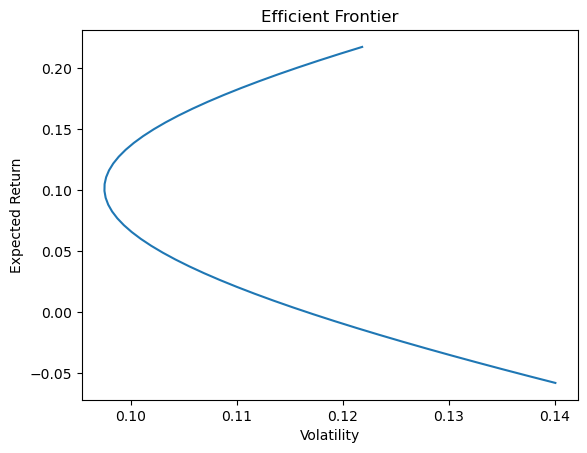

In [6]:
ef = EfficientFrontier(mu, Sigma)

frontier_returns, frontier_vols, frontier_weights = ef.frontier()

plt.plot(frontier_vols, frontier_returns)
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier")
plt.savefig('eff_front.png',dpi=300)
plt.show()

## Tangency Portfolio (Maximum Sharpe Portfolio)

When a risk-free asset exists with return $r_f$, the optimal risky portfolio is:
$\underset{w}{max} \,\frac{w^T\mu - r_f}{\sqrt{w^T\Sigma w}}$ which maximizes the Sharpe ratio.

The tangency portfolio: $w^* \propto \Sigma^{-1}\mu$

Large weights occur when:
- High expected return
- Low covariance with others
  
Highly sensitive to μ estimation error

In [7]:
optimizer = PortfolioOptimizer(mu, Sigma, rf=0.02)

w_tan = optimizer.tangency_weights()

ret, vol, sharpe = optimizer.portfolio_performance(w_tan)

print("Tangency Portfolio Weights:")
print(w_tan)

print("\nExpected Return:", ret)
print("Volatility:", vol)
print("Sharpe Ratio:", sharpe)

Tangency Portfolio Weights:
[-0.33192205  0.95493014 -0.87217859 -0.84038839  2.64243159 -0.5528727 ]

Expected Return: 0.3956560380954755
Volatility: 0.20960040072285122
Sharpe Ratio: 1.7922486636473325


### Visualizing Tangency on Frontier

Geometrically: The tangency portfolio is the point where a line from $r_f$ is tangent to the efficient frontier.

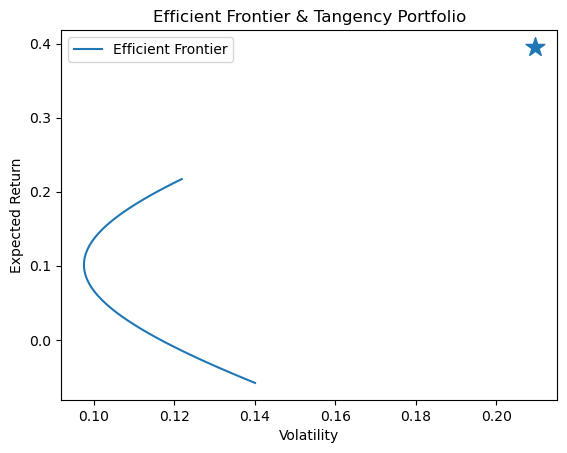

In [8]:
plt.plot(frontier_vols, frontier_returns, label="Efficient Frontier")

plt.scatter(vol, ret, marker="*", s=200)
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier & Tangency Portfolio")
plt.legend()
plt.savefig('eff_tangent.png',dpi=300)
plt.show()

## Covariance Diagnostics & Stability

Markowitz optimization depends entirely on: $\Sigma^{-1}$ If $\Sigma$ is ill-conditioned, weights become unstable.

The condition number of a matrix is: $\kappa(\Sigma) = \frac{\lambda_{max}}{\lambda_{min}}$

Optimization procedure for
- $\kappa \approx 1$: perfectly stable
- $\kappa < 100$: stable
- $\kappa \in (100,1000)$: moderately stable
- $\kappa > 1000$: unstable

Large $\kappa$ means small estimation errors in $\Sigma$ cause large changes in $\Sigma^{-1}$ which causes extreme portfolio weights.

In [9]:
diag = CovarianceDiagnostics(Sigma)

eigvals = diag.eigenvalues()
cond_number = diag.condition_number()

print("Eigenvalues:")
print(eigvals)

print("\nCondition Number:", cond_number)
print("Positive Definite:", diag.is_positive_definite())

Eigenvalues:
[0.0012735  0.00740293 0.01277613 0.02124655 0.03324291 0.1350421 ]

Condition Number: 106.04044131181817
Positive Definite: True


### Plot Eigenvalue Spectrum

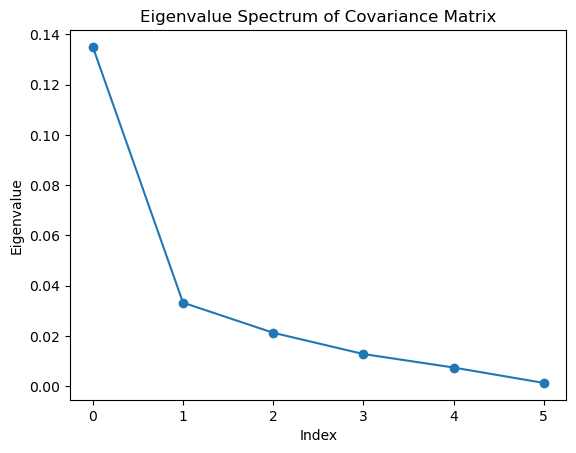

In [10]:
plt.plot(sorted(eigvals, reverse=True), marker="o")
plt.title("Eigenvalue Spectrum of Covariance Matrix")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.savefig('eigenval.png',dpi=300)
plt.show()

## Weight Instability (Rolling Window Analysis)

Markowitz portfolios are notoriously unstable because: $w^* \propto \Sigma^{-1}\mu$

Both $\mu$ and $\Sigma$ are estimated, not known. Small estimation noise → large weight variation.

Instead of estimating parameters once using the full 5-year sample, we use a rolling window of 3 years (for e.g.) and estimate weights for this period and roll forward for one month and reestimate and repeat. This produces a time series of weights $w_t$. If it fluctuates wildly → instability confirmed.

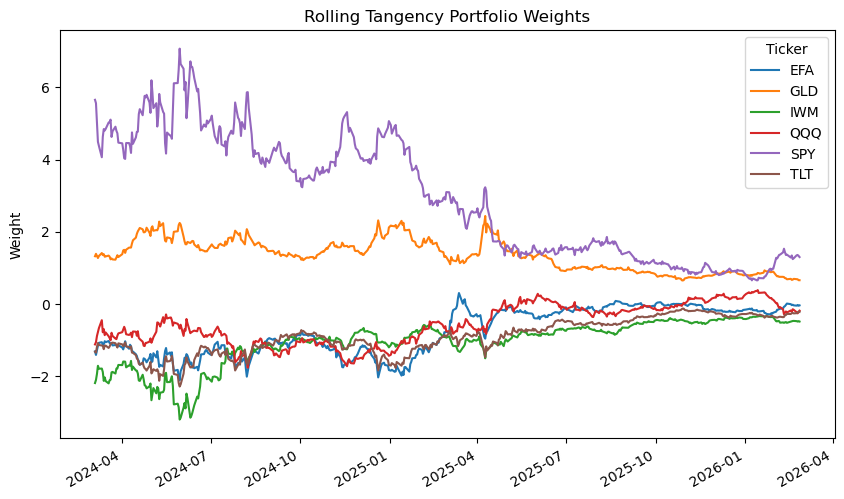

In [11]:
analyzer = StabilityAnalyzer(returns, window=756, rf=0.02)

rolling_w = analyzer.rolling_weights()

rolling_w.plot(figsize=(10,6))
plt.title("Rolling Tangency Portfolio Weights")
plt.ylabel("Weight")
plt.savefig('roll_tang.png',dpi=300)
plt.show()

## Out-of-Sample Backtest

Using past few days to estimate $\mu$ and $\Sigma$ to compute weights and apply these weights for next day return. This prevents look-ahead bias.

In [12]:
backtester = Backtester(returns, window=756, rf=0.02)

portfolio_returns = backtester.run()

ann_ret, ann_vol, sharpe = backtester.performance_metrics(portfolio_returns)

print("Out-of-Sample Performance")
print("Annual Return:", ann_ret)
print("Annual Vol:", ann_vol)
print("Sharpe:", sharpe)

Out-of-Sample Performance
Annual Return: 0.6401708331428636
Annual Vol: 0.3523474688415592
Sharpe: 1.760111503516255


### Plot Cumulative Performance

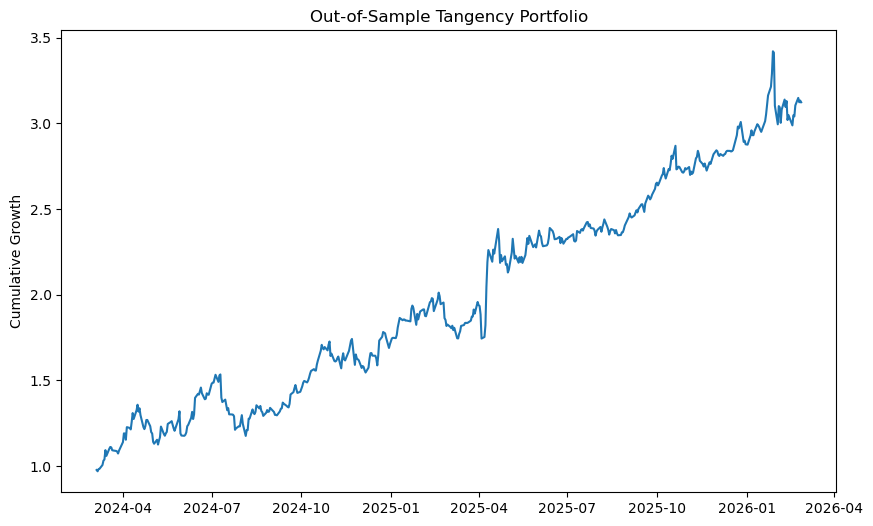

In [13]:
cumulative = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(10,6))
plt.plot(cumulative)
plt.title("Out-of-Sample Tangency Portfolio")
plt.ylabel("Cumulative Growth")
plt.savefig('out_sampl.png',dpi=300)
plt.show()

### Compare With In-Sample Tangency

In [14]:
optimizer_full = PortfolioOptimizer(mu, Sigma, rf=0.02)
w_full = optimizer_full.tangency_weights()

in_sample_ret, in_sample_vol, in_sample_sharpe = optimizer_full.portfolio_performance(w_full)

print("In-Sample Sharpe:", in_sample_sharpe)

In-Sample Sharpe: 1.7922486636473325


## Long-only Mean–Variance Optimization

### 1. Classical (Unconstrained) Problem:

- In the standard Markowitz framework, we solve: $$\min_{w} \; w^T \Sigma w$$ subject to:$$w^T \mu = \mu^*, \quad \mathbf{1}^T w = 1$$
- The tangency (maximum Sharpe) portfolio with risk-free rate $r_f$ has closed-form solution: $$w^* =\frac{\Sigma^{-1}(\mu - r_f \mathbf{1})}{\mathbf{1}^T \Sigma^{-1}(\mu - r_f \mathbf{1})}$$ This solution allows negative weights (short-selling).

### 2. Long-Only Constraint:

- In realistic portfolio construction, we often impose: $w_i > 0 \forall i$
- The constrained minimum-variance problem becomes: $$\min_{w} \; w^T \Sigma w$$ $$
\text{subject to} \quad 
w^T \mu \ge \mu^*, 
\quad 
\mathbf{1}^T w = 1, 
\quad 
w \ge 0
$$

### 3. Long-Only Maximum Sharpe Portfolio:

We solve
$$
\max_{w} 
\frac{w^T (\mu - r_f \mathbf{1})}
{\sqrt{w^T \Sigma w}}
$$
$$
\text{subject to} \quad 
\mathbf{1}^T w = 1, 
\quad 
w \ge 0
$$

We evaluate the Sharpe ratio
$$
\text{Sharpe}(w) =
\frac{w^T \mu - r_f}
{\sqrt{w^T \Sigma w}}
$$
Select the portfolio on the frontier that maximizes Sharpe.

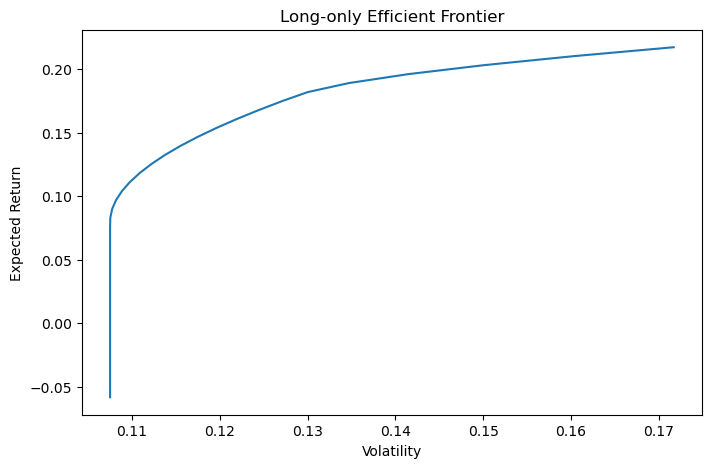

Long-only Max Sharpe weights: [ 5.08081714e-24  6.88491079e-01  9.35728935e-24 -5.66406768e-24
  3.11508921e-01  3.28208675e-23]
Return: 0.18922699956692082 Vol: 0.13497399150855982 Sharpe: 1.2537748767412626


In [4]:
mu = returns.mean() * 252
Sigma = returns.cov() * 252

copt = ConstrainedOptimizer(mu, Sigma, rf=0.02)

# Long-only frontier
frontier_mu, frontier_vol, frontier_w = copt.frontier(num_points=40)

plt.figure(figsize=(8,5))
plt.plot(frontier_vol, frontier_mu)
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Long-only Efficient Frontier")
plt.savefig('long_eff_front.png',dpi=300)
plt.show()

# Long-only max Sharpe (robust)
w_long_sharpe = copt.max_sharpe(num_points=80)
r, v, s = copt.performance(w_long_sharpe)

print("Long-only Max Sharpe weights:", w_long_sharpe)
print("Return:", r, "Vol:", v, "Sharpe:", s)

## Covariance shrinkage (Ledoit–Wolf)

- Sample Covariance Estimator

$$
\hat{\Sigma}_{\text{sample}}=
\frac{1}{T-1}
\sum_{t=1}^{T}
(R_t - \bar{R})(R_t - \bar{R})^T
$$
where $$\bar{R} = \frac{1}{T} \sum_{t=1}^{T} R_t$$

- Shrinkage Covariance Estimator
Instead of using $\hat{\Sigma}_{\text{sample}}$ directly, we shrink it toward a structured target matrix $F$:
$$\hat{\Sigma}_{\text{shrunk}}=(1-\delta)\hat{\Sigma}_{\text{sample}}+\delta F$$ where $$0 \le \delta \le 1$$

- Ledoit–Wolf Target
  
Target Matrix (Scaled Identity): $$F = \bar{\sigma}^2 I$$ where $$\bar{\sigma}^2=\frac{1}{N}\sum_{i=1}^{N}\hat{\Sigma}_{ii}=\frac{\text{trace}(\hat{\Sigma})}{N}$$

Final Shrinkage Estimator where $\delta^*$ is optimally estimated by the Ledoit–Wolf method.
$$
\hat{\Sigma}_{LW}=
(1-\delta^*)\hat{\Sigma}_{\text{sample}}
+
\delta^* \bar{\sigma}^2 I
$$

- Interpretation
when $\delta=0$: $$\hat{\Sigma}_{\text{shrunk}} = \hat{\Sigma}_{\text{sample}}$$
when $\delta=1$: $$\hat{\Sigma}_{\text{shrunk}} = F$$

- Effect on Conditioning
- 
Shrinkage improves conditioning
$$\kappa(\hat{\Sigma}_{\text{shrunk}})<\kappa(\hat{\Sigma}_{\text{sample}})$$
where $$\kappa(\Sigma)=\frac{\lambda_{\max}}{\lambda_{\min}}$$

Tangency Portfolio with Shrinkage $$
w^* =
\frac{\hat{\Sigma}_{\text{shrunk}}^{-1}(\mu - r_f \mathbf{1})}
{\mathbf{1}^T \hat{\Sigma}_{\text{shrunk}}^{-1}(\mu - r_f \mathbf{1})}
$$

### compute sample vs Ledoit–Wolf Σ

In [5]:
# returns: DataFrame of daily log returns (T x N)
mu = returns.mean() * 252

Sigma_sample = returns.cov() * 252

lw = LedoitWolfShrinkage(returns, trading_days=252)
Sigma_lw, delta = lw.fit()

print("Ledoit–Wolf shrinkage intensity delta:", delta)

Ledoit–Wolf shrinkage intensity delta: 0.011476817611526233


### compare conditioning + eigenvalues

In [6]:
def cond_number(Sigma):
    eigvals = np.linalg.eigvalsh(Sigma.values if hasattr(Sigma, "values") else Sigma)
    return float(eigvals.max() / eigvals.min()), eigvals

cond_s, eig_s = cond_number(Sigma_sample)
cond_lw, eig_lw = cond_number(Sigma_lw)

print("Condition number (sample):", cond_s)
print("Condition number (Ledoit–Wolf):", cond_lw)
print("Eigenvalues (sample):", eig_s)
print("Eigenvalues (Ledoit–Wolf):", eig_lw)

Condition number (sample): 106.05989385159175
Condition number (Ledoit–Wolf): 80.55342589396132
Eigenvalues (sample): [0.00127349 0.00740302 0.01277725 0.02124663 0.03324376 0.13506638]
Eigenvalues (Ledoit–Wolf): [0.00166117 0.00771553 0.01302383 0.02138934 0.03323932 0.13381308]


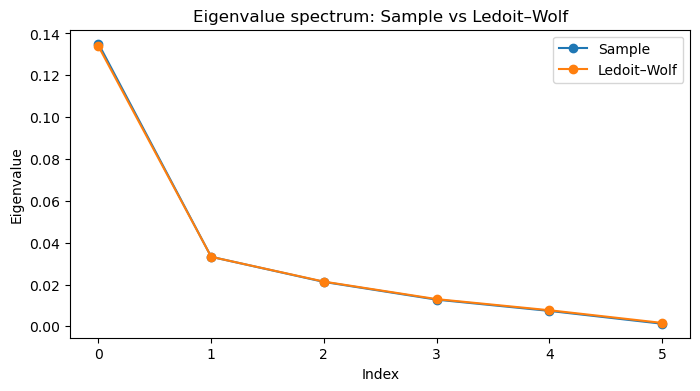

In [10]:
plt.figure(figsize=(8,4))
plt.plot(sorted(eig_s, reverse=True), marker="o", label="Sample")
plt.plot(sorted(eig_lw, reverse=True), marker="o", label="Ledoit–Wolf")
plt.title("Eigenvalue spectrum: Sample vs Ledoit–Wolf")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.legend()
plt.savefig('eigen_sampl_vs_lf.png',dpi=300)
plt.show()

### Compare long-only max Sharpe weights (sample vs LW)

In [8]:
# Sample
copt_s = ConstrainedOptimizer(mu, Sigma_sample, rf=0.02)
w_s = copt_s.max_sharpe(num_points=80)
r_s, v_s, sh_s = copt_s.performance(w_s)

# Ledoit–Wolf
copt_lw = ConstrainedOptimizer(mu, Sigma_lw, rf=0.02)
w_lw = copt_lw.max_sharpe(num_points=80)
r_lw, v_lw, sh_lw = copt_lw.performance(w_lw)

weights_compare = pd.DataFrame(
    {"w_sample": w_s, "w_lw": w_lw},
    index=returns.columns
)

print(weights_compare)
print("\nSample long-only max Sharpe:", sh_s)
print("LW long-only max Sharpe:", sh_lw)

            w_sample          w_lw
Ticker                            
EFA     5.080817e-24  8.543650e-24
GLD     6.884911e-01  6.884911e-01
IWM     9.357289e-24  9.123421e-24
QQQ    -5.664068e-24 -8.206528e-24
SPY     3.115089e-01  3.115089e-01
TLT     3.282087e-23  4.486315e-23

Sample long-only max Sharpe: 1.2537748767412626
LW long-only max Sharpe: 1.2535388242713499


### Out-of-sample backtest: sample vs LW covariance (rolling)

/home/poddar/anaconda3/lib/python3.9/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/poddar/anaconda3/lib/python3.9/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/poddar/anaconda3/lib/python3.9/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/poddar/anaconda3/lib/python3.9/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/poddar/anaconda3/lib/python3.9

OOS (Sample)  ann_ret, ann_vol, sharpe: (0.3294890757054704, 0.15896014143089354, 1.9469602437414661)
OOS (LW)      ann_ret, ann_vol, sharpe: (0.3297394290138714, 0.15832993149581145, 1.9562910568306875)


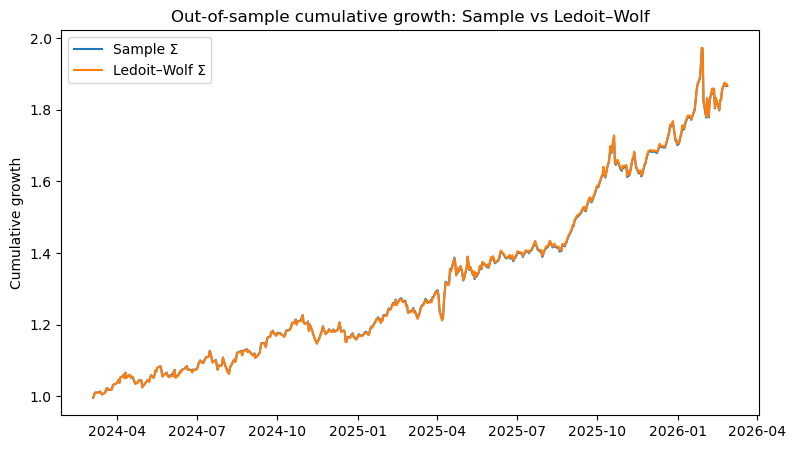

In [9]:
bt = BacktesterShrinkage(returns, window=756, rf=0.02, frontier_points=60)
oos_sample, oos_lw, met_sample, met_lw = bt.run()

print("OOS (Sample)  ann_ret, ann_vol, sharpe:", met_sample)
print("OOS (LW)      ann_ret, ann_vol, sharpe:", met_lw)

cum_s = (1 + oos_sample).cumprod()
cum_lw = (1 + oos_lw).cumprod()

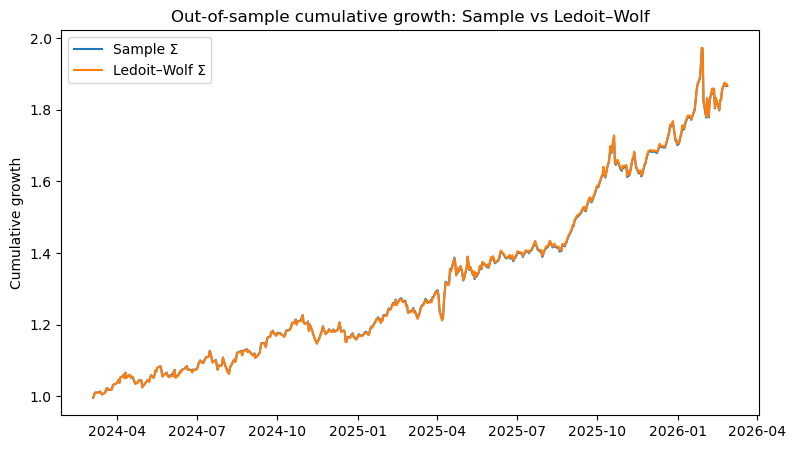

In [11]:
plt.figure(figsize=(9,5))
plt.plot(cum_s, label="Sample Σ")
plt.plot(cum_lw, label="Ledoit–Wolf Σ")
plt.title("Out-of-sample cumulative growth: Sample vs Ledoit–Wolf")
plt.ylabel("Cumulative growth")
plt.legend()
plt.savefig('sampl_vs_cov.png',dpi=300)
plt.show()

### Concentration + Turnover Metrics

Effective number of positions:$$
HHI = \sum_{i=1}^{N} w_i^2
$$$$
N_{\text{eff}} = \frac{1}{\sum_{i=1}^{N} w_i^2}
$$
Where:

- $HHI$ = Herfindahl–Hirschman Index

- $N_{\text{eff}}$ = effective number of positions

Interpretation:

- If portfolio is equally weighted:
$N_{\text{eff}} = N$

- If fully concentrated in one asset:
$N_{\text{eff}} = 1$

Turnover between periods:
$$
\text{Turnover}_t=
\sum_{i=1}^{N}
\left|
w_{t,i} - w_{t-1,i}
\right|
$$
High turnover indicates instability and trading costs.

In [12]:
def concentration_metrics(weights):
    """
    weights: 1D numpy array
    """
    hhi = np.sum(weights**2)
    n_eff = 1.0 / hhi
    return hhi, n_eff


# Example: long-only max Sharpe weights
hhi_s, n_eff_s = concentration_metrics(w_s)
hhi_lw, n_eff_lw = concentration_metrics(w_lw)

print("Sample Σ  -> HHI:", hhi_s, "Effective N:", n_eff_s)
print("LW Σ      -> HHI:", hhi_lw, "Effective N:", n_eff_lw)

Sample Σ  -> HHI: 0.5710577734488288 Effective N: 1.7511363061580103
LW Σ      -> HHI: 0.5710577734488288 Effective N: 1.7511363061580103


Average Turnover: 0.40584063719534413


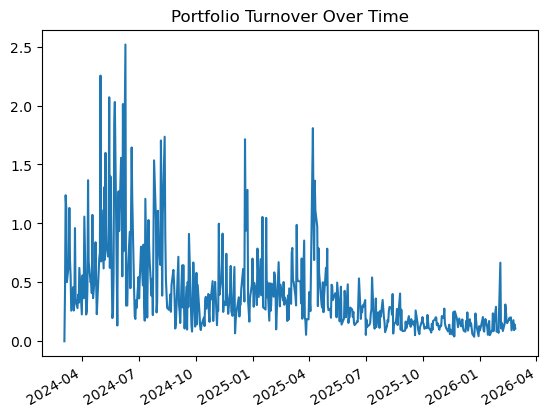

In [16]:
# Turnover time series
turnover = rolling_w.diff().abs().sum(axis=1)

print("Average Turnover:", turnover.mean())

turnover.plot(title="Portfolio Turnover Over Time")
plt.show()

### Interpretation

Typically:

- Sample covariance → higher concentration (lower N_eff)

- Shrinkage → more diversified weights

- Long-only → lower turnover than unconstrained